Resumes DataFrame columns: ['id', 'name', 'education', 'skills', 'experience', 'previous_jobs', 'fresher_flag']
Jobs DataFrame columns: ['title', 'department', 'location', 'required_skills', 'experience_required', 'education_required', 'certifications_required', 'job_description']

=== QUICK PREDICTION (UNSUPERVISED: Cosine Similarity) ===

Candidate: Candidate_1
  Match 1: Backend Developer (11.98%)
  Match 2: Project Manager (11.01%)
  Match 3: Java Developer (9.20%)

Candidate: Candidate_2
  Match 1: Project Manager (37.58%)
  Match 2: Backend Developer (32.85%)
  Match 3: DevOps Engineer (21.67%)

Candidate: Candidate_3
  Match 1: Backend Developer (11.98%)
  Match 2: Project Manager (11.01%)
  Match 3: Java Developer (9.20%)

Candidate: Candidate_4
  Match 1: Project Manager (27.20%)
  Match 2: Android Developer (20.81%)
  Match 3: Web Developer (14.47%)

Candidate: Candidate_5
  Match 1: Project Manager (27.20%)
  Match 2: Android Developer (20.81%)
  Match 3: Web Developer (14.4

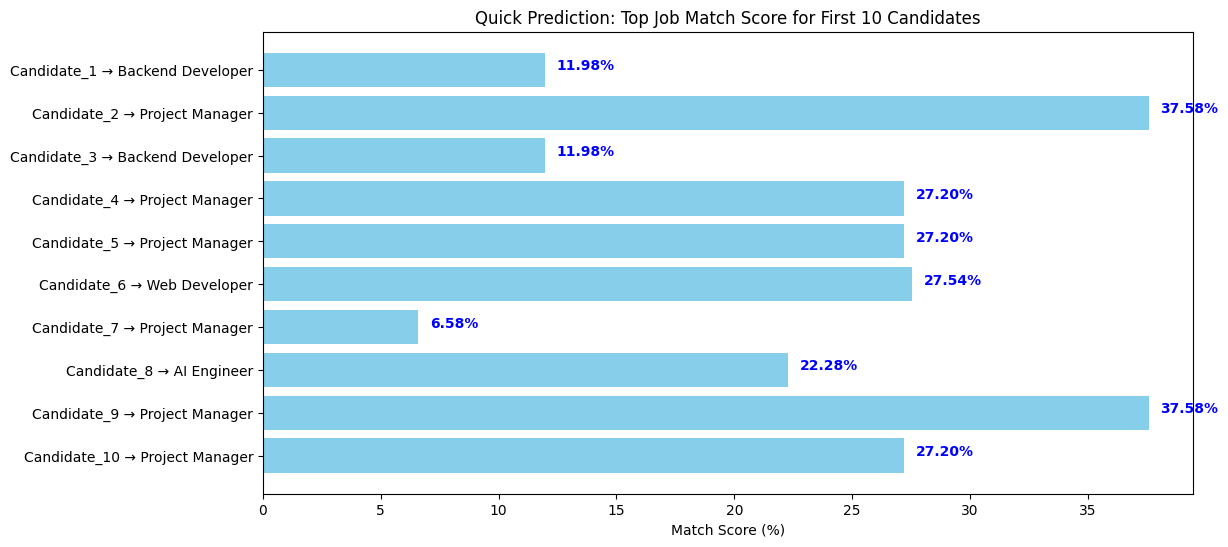


=== DEEP PREDICTION (SUPERVISED MODELS) ===


Logistic Regression:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        17

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



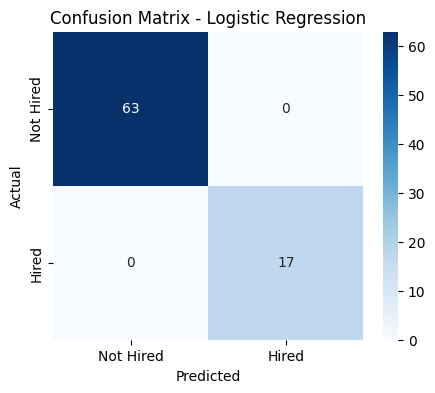


SVM:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        17

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



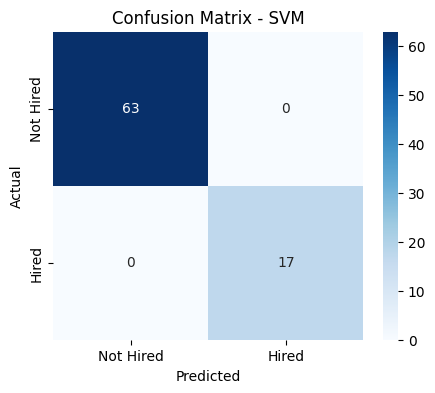


Random Forest:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        17

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



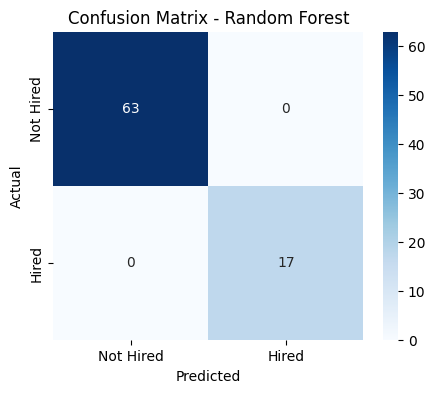


AdaBoost:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        17

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



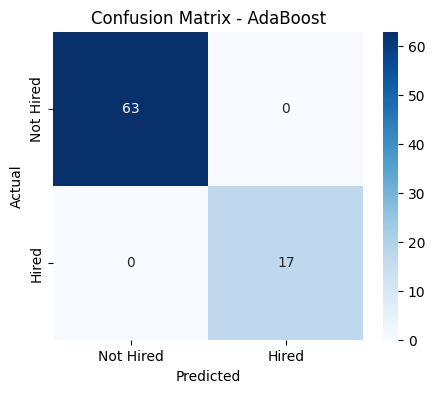

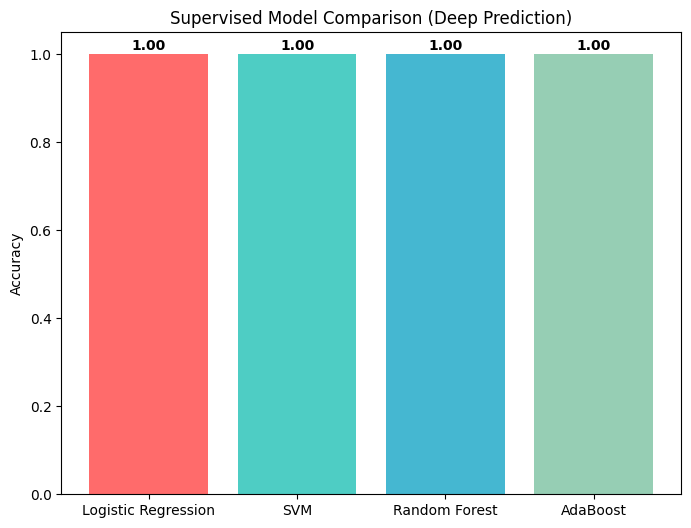

In [1]:
# =====================================================
# SECTION 1: HYBRID RESUME SCREENING (QUICK + DEEP)
# =====================================================

import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# 1. Load datasets
resumes_df = pd.read_csv("resumes_dataset_400.csv")
jobs_df = pd.read_csv("job_descriptions_50.csv")

# Check dataset columns
print("Resumes DataFrame columns:", resumes_df.columns.tolist())
print("Jobs DataFrame columns:", jobs_df.columns.tolist())

# 2. Preprocessing function
def preprocess_skills(skills_text):
    skills_text = str(skills_text).lower()
    skills_text = re.sub(r'[^a-z,\s]', '', skills_text)  # keep only alphabets, commas, spaces
    tokens = [t.strip() for t in skills_text.split(",") if t.strip()]
    tokens = list(set(tokens))  # remove duplicates
    return ' '.join(tokens)

# Apply preprocessing
resumes_df['cleaned_skills'] = resumes_df['skills'].apply(preprocess_skills)
jobs_df['cleaned_required_skills'] = jobs_df['required_skills'].apply(preprocess_skills)

# 3. TF-IDF Vectorization
vectorizer = TfidfVectorizer(analyzer='word', token_pattern=r'\w+')
vectorizer.fit(pd.concat([resumes_df['cleaned_skills'], jobs_df['cleaned_required_skills']]))

resume_vectors = vectorizer.transform(resumes_df['cleaned_skills'])
job_vectors = vectorizer.transform(jobs_df['cleaned_required_skills'])

# =====================================================
# PART A: UNSUPERVISED MATCHING (QUICK PREDICTION)
# =====================================================
print("\n=== QUICK PREDICTION (UNSUPERVISED: Cosine Similarity) ===\n")

# Compute cosine similarity = match score
match_scores = cosine_similarity(resume_vectors, job_vectors)

# Show top 3 matches for first 5 candidates
for i in range(5):
    candidate_name = resumes_df.loc[i, 'name']
    scores = match_scores[i]
    top_jobs = scores.argsort()[-3:][::-1]
    print(f"Candidate: {candidate_name}")
    for rank, job_idx in enumerate(top_jobs, start=1):
        job_title = jobs_df.loc[job_idx, 'title']
        score = scores[job_idx] * 100
        print(f"  Match {rank}: {job_title} ({score:.2f}%)")
    print()

# Visualization: Top job match for first 10 candidates
top_matches = []
for i in range(10):
    best_job_index = match_scores[i].argmax()
    score = match_scores[i][best_job_index] * 100
    candidate_name = resumes_df.loc[i, 'name']
    job_title = jobs_df.loc[best_job_index, 'title']
    top_matches.append((f"{candidate_name} → {job_title}", score))

labels, scores = zip(*top_matches)
plt.figure(figsize=(12,6))
plt.barh(labels, scores, color="skyblue")
plt.xlabel("Match Score (%)")
plt.title("Quick Prediction: Top Job Match Score for First 10 Candidates")
plt.gca().invert_yaxis()
for i, v in enumerate(scores):
    plt.text(v + 0.5, i, f"{v:.2f}%", color="blue", fontweight="bold")
plt.show()

# =====================================================
# PART B: SUPERVISED LEARNING (DEEP PREDICTION)
# =====================================================
print("\n=== DEEP PREDICTION (SUPERVISED MODELS) ===\n")

# For supervised learning, create labels:
# Example: 'hired' column in resumes dataset (1 = suitable, 0 = not suitable)
# If you don’t have it, you can simulate based on match score threshold
if 'hired' not in resumes_df.columns:
    resumes_df['hired'] = (match_scores.max(axis=1) > 0.3).astype(int)  # threshold-based labels

# Features = resume skills (TF-IDF vectors)
X = resume_vectors
y = resumes_df['hired']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='linear', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "AdaBoost": AdaBoostClassifier(n_estimators=100)
}

results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[model_name] = acc
    print(f"\n{model_name}:")
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Hired","Hired"], yticklabels=["Not Hired","Hired"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Compare model performance
plt.figure(figsize=(8,6))
plt.bar(results.keys(), results.values(), color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4'])
plt.ylabel("Accuracy")
plt.title("Supervised Model Comparison (Deep Prediction)")
for i, (model, acc) in enumerate(results.items()):
    plt.text(i, acc+0.01, f"{acc:.2f}", ha='center', fontweight='bold')
plt.show()


Resumes DataFrame columns: ['id', 'name', 'education', 'skills', 'experience', 'previous_jobs', 'fresher_flag']
Jobs DataFrame columns: ['title', 'department', 'location', 'required_skills', 'experience_required', 'education_required', 'certifications_required', 'job_description']

=== QUICK PREDICTION (UNSUPERVISED: Cosine Similarity) ===

Candidate: Candidate_1
  Match 1: Backend Developer (11.98%)
  Match 2: Project Manager (11.01%)
  Match 3: Java Developer (9.20%)

Candidate: Candidate_2
  Match 1: Project Manager (37.58%)
  Match 2: Backend Developer (32.85%)
  Match 3: DevOps Engineer (21.67%)

Candidate: Candidate_3
  Match 1: Backend Developer (11.98%)
  Match 2: Project Manager (11.01%)
  Match 3: Java Developer (9.20%)

Candidate: Candidate_4
  Match 1: Project Manager (27.20%)
  Match 2: Android Developer (20.81%)
  Match 3: Web Developer (14.47%)

Candidate: Candidate_5
  Match 1: Project Manager (27.20%)
  Match 2: Android Developer (20.81%)
  Match 3: Web Developer (14.4

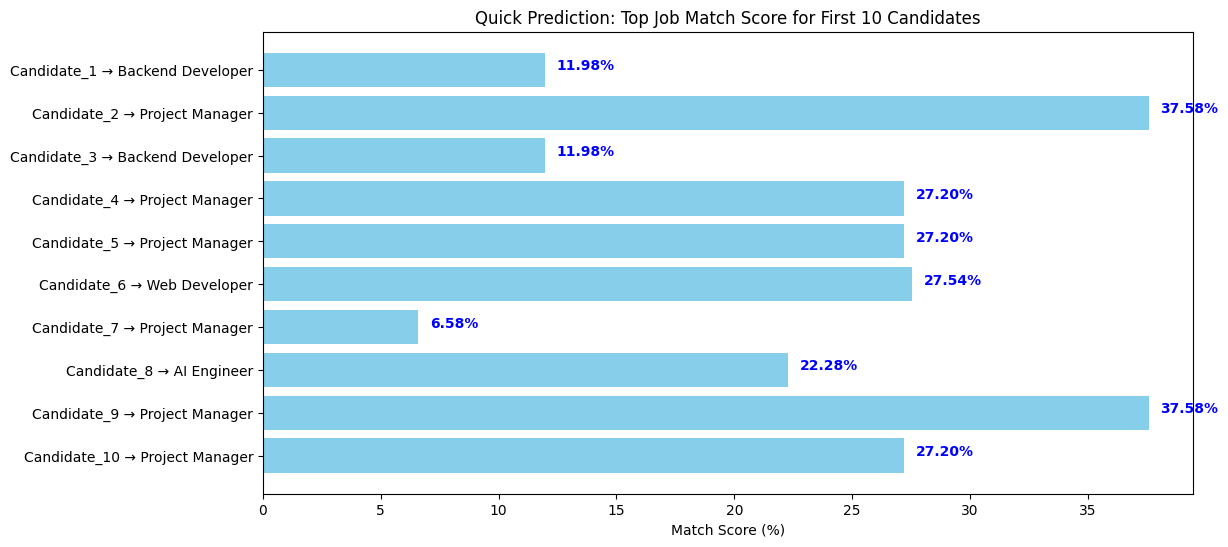


=== DEEP PREDICTION (SUPERVISED MODELS) ===


Logistic Regression:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        17

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



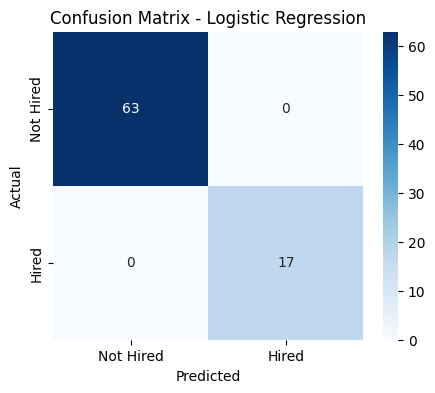


SVM:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        17

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



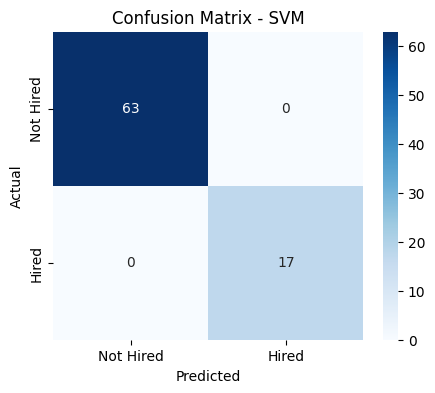


Random Forest:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        17

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



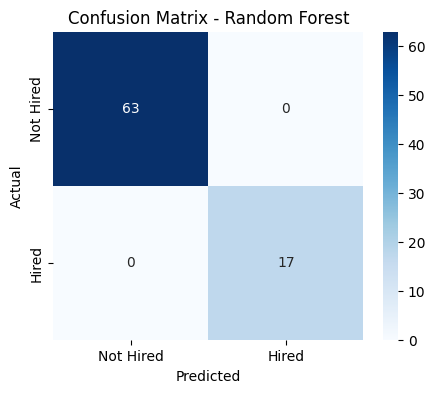


AdaBoost:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        17

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



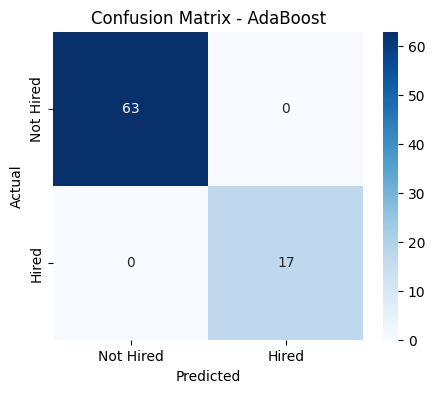


=== BEST MODEL SELECTED: Logistic Regression ===
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        17

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



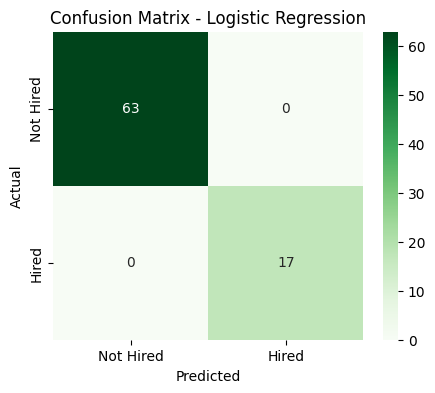

In [2]:
# ================================================
# HYBRID RESUME SCREENING SYSTEM
# ================================================

# Import necessary libraries
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# -----------------------------------------------
# STEP 1: Load Resume and Job Description Datasets
# -----------------------------------------------
resumes_df = pd.read_csv("resumes_dataset_400.csv")
jobs_df = pd.read_csv("job_descriptions_50.csv")

# Display column names for reference
print("Resumes DataFrame columns:", resumes_df.columns.tolist())
print("Jobs DataFrame columns:", jobs_df.columns.tolist())

# -----------------------------------------------
# STEP 2: Preprocess Skills Text
# -----------------------------------------------
def preprocess_skills(skills_text):
    skills_text = str(skills_text).lower()
    skills_text = re.sub(r'[^a-z,\s]', '', skills_text)  # keep only alphabets, commas, spaces
    tokens = [t.strip() for t in skills_text.split(",") if t.strip()]
    tokens = list(set(tokens))  # remove duplicates
    return ' '.join(tokens)

# Apply preprocessing to both datasets
resumes_df['cleaned_skills'] = resumes_df['skills'].apply(preprocess_skills)
jobs_df['cleaned_required_skills'] = jobs_df['required_skills'].apply(preprocess_skills)

# -----------------------------------------------
# STEP 3: TF-IDF Vectorization of Skills
# -----------------------------------------------
vectorizer = TfidfVectorizer(analyzer='word', token_pattern=r'\w+')
vectorizer.fit(pd.concat([resumes_df['cleaned_skills'], jobs_df['cleaned_required_skills']]))

resume_vectors = vectorizer.transform(resumes_df['cleaned_skills'])
job_vectors = vectorizer.transform(jobs_df['cleaned_required_skills'])

# -----------------------------------------------
# PART A: QUICK PREDICTION (UNSUPERVISED MATCHING)
# -----------------------------------------------
print("\n=== QUICK PREDICTION (UNSUPERVISED: Cosine Similarity) ===\n")

# Compute cosine similarity between resumes and jobs
match_scores = cosine_similarity(resume_vectors, job_vectors)

# Display top 3 job matches for first 5 candidates
for i in range(5):
    candidate_name = resumes_df.loc[i, 'name']
    scores = match_scores[i]
    top_jobs = scores.argsort()[-3:][::-1]
    print(f"Candidate: {candidate_name}")
    for rank, job_idx in enumerate(top_jobs, start=1):
        job_title = jobs_df.loc[job_idx, 'title']
        score = scores[job_idx] * 100
        print(f"  Match {rank}: {job_title} ({score:.2f}%)")
    print()

# Visualize top job match for first 10 candidates
top_matches = []
for i in range(10):
    best_job_index = match_scores[i].argmax()
    score = match_scores[i][best_job_index] * 100
    candidate_name = resumes_df.loc[i, 'name']
    job_title = jobs_df.loc[best_job_index, 'title']
    top_matches.append((f"{candidate_name} → {job_title}", score))

labels, scores = zip(*top_matches)
plt.figure(figsize=(12,6))
plt.barh(labels, scores, color="skyblue")
plt.xlabel("Match Score (%)")
plt.title("Quick Prediction: Top Job Match Score for First 10 Candidates")
plt.gca().invert_yaxis()
for i, v in enumerate(scores):
    plt.text(v + 0.5, i, f"{v:.2f}%", color="blue", fontweight="bold")
plt.show()

# -----------------------------------------------
# PART B: DEEP PREDICTION (SUPERVISED LEARNING)
# -----------------------------------------------
print("\n=== DEEP PREDICTION (SUPERVISED MODELS) ===\n")

# Create labels if not present (simulate based on match score threshold)
if 'hired' not in resumes_df.columns:
    resumes_df['hired'] = (match_scores.max(axis=1) > 0.3).astype(int)

# Define features and labels
X = resume_vectors
y = resumes_df['hired']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define supervised models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='linear', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "AdaBoost": AdaBoostClassifier(n_estimators=100)
}

# Train and evaluate each model
results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[model_name] = acc
    print(f"\n{model_name}:")
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Hired","Hired"], yticklabels=["Not Hired","Hired"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# -----------------------------------------------
# STEP 4: Display Only the Best Model
# -----------------------------------------------
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

# Retrain and evaluate best model
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print(f"\n=== BEST MODEL SELECTED: {best_model_name} ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Classification Report:\n", classification_report(y_test, y_pred_best))

# Confusion Matrix for best model
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Greens", xticklabels=["Not Hired","Hired"], yticklabels=["Not Hired","Hired"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Resumes DataFrame columns: ['id', 'name', 'education', 'skills', 'experience', 'previous_jobs', 'fresher_flag']
Jobs DataFrame columns: ['title', 'department', 'location', 'required_skills', 'experience_required', 'education_required', 'certifications_required', 'job_description']

=== QUICK PREDICTION (UNSUPERVISED: Cosine Similarity) ===

Candidate: Candidate_1
  Match 1: Backend Developer (11.98%)
  Match 2: Project Manager (11.01%)
  Match 3: Java Developer (9.20%)

Candidate: Candidate_2
  Match 1: Project Manager (37.58%)
  Match 2: Backend Developer (32.85%)
  Match 3: DevOps Engineer (21.67%)

Candidate: Candidate_3
  Match 1: Backend Developer (11.98%)
  Match 2: Project Manager (11.01%)
  Match 3: Java Developer (9.20%)

Candidate: Candidate_4
  Match 1: Project Manager (27.20%)
  Match 2: Android Developer (20.81%)
  Match 3: Web Developer (14.47%)

Candidate: Candidate_5
  Match 1: Project Manager (27.20%)
  Match 2: Android Developer (20.81%)
  Match 3: Web Developer (14.4

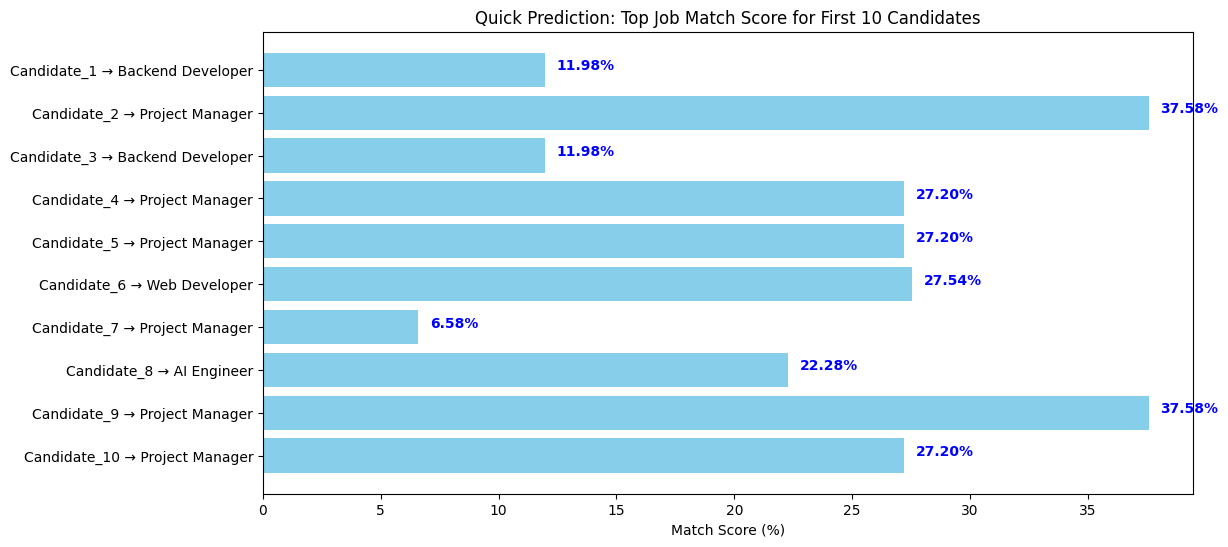


=== DEEP PREDICTION (SUPERVISED MODELS) ===


Logistic Regression:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        17

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



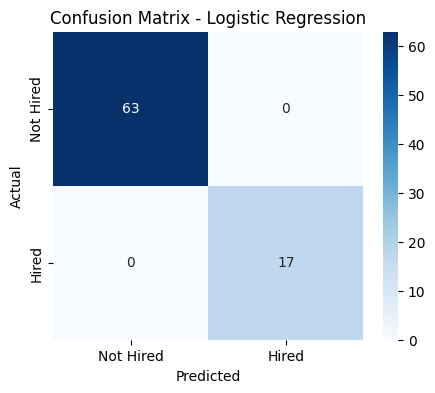


SVM:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        17

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



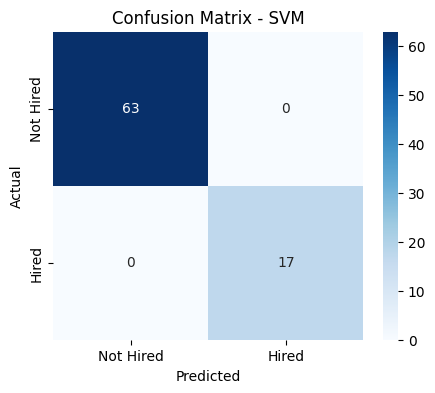


Random Forest:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        17

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



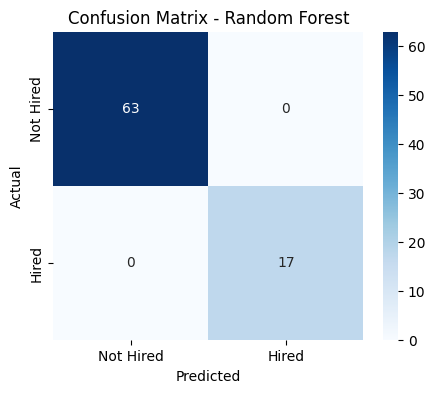


AdaBoost:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        17

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



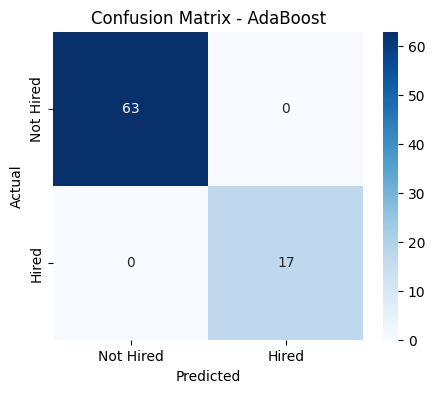

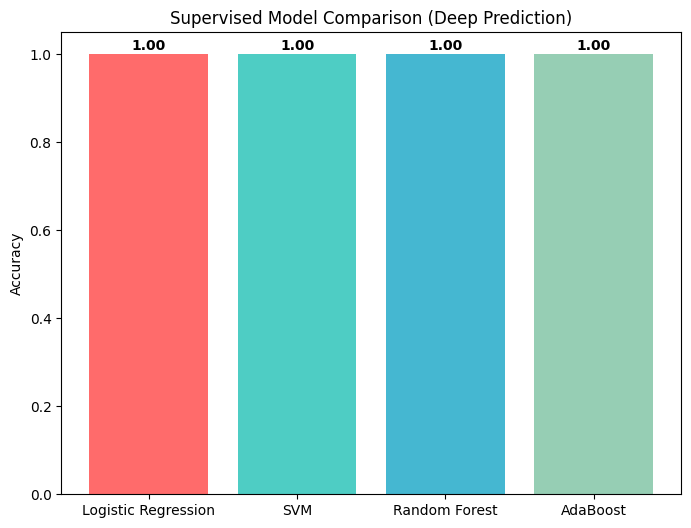

In [1]:
# =====================================================
# SECTION 1: HYBRID RESUME SCREENING (QUICK + DEEP)
# =====================================================

import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# 1. Load datasets
resumes_df = pd.read_csv("resumes_dataset_400.csv")
jobs_df = pd.read_csv("job_descriptions_50.csv")

# Check dataset columns
print("Resumes DataFrame columns:", resumes_df.columns.tolist())
print("Jobs DataFrame columns:", jobs_df.columns.tolist())

# 2. Preprocessing function
def preprocess_skills(skills_text):
    skills_text = str(skills_text).lower()
    skills_text = re.sub(r'[^a-z,\s]', '', skills_text)  # keep only alphabets, commas, spaces
    tokens = [t.strip() for t in skills_text.split(",") if t.strip()]
    tokens = list(set(tokens))  # remove duplicates
    return ' '.join(tokens)

# Apply preprocessing
resumes_df['cleaned_skills'] = resumes_df['skills'].apply(preprocess_skills)
jobs_df['cleaned_required_skills'] = jobs_df['required_skills'].apply(preprocess_skills)

# 3. TF-IDF Vectorization
vectorizer = TfidfVectorizer(analyzer='word', token_pattern=r'\w+')
vectorizer.fit(pd.concat([resumes_df['cleaned_skills'], jobs_df['cleaned_required_skills']]))

resume_vectors = vectorizer.transform(resumes_df['cleaned_skills'])
job_vectors = vectorizer.transform(jobs_df['cleaned_required_skills'])

# =====================================================
# PART A: UNSUPERVISED MATCHING (QUICK PREDICTION)
# =====================================================
print("\n=== QUICK PREDICTION (UNSUPERVISED: Cosine Similarity) ===\n")

# Compute cosine similarity = match score
match_scores = cosine_similarity(resume_vectors, job_vectors)

# Show top 3 matches for first 5 candidates
for i in range(5):
    candidate_name = resumes_df.loc[i, 'name']
    scores = match_scores[i]
    top_jobs = scores.argsort()[-3:][::-1]
    print(f"Candidate: {candidate_name}")
    for rank, job_idx in enumerate(top_jobs, start=1):
        job_title = jobs_df.loc[job_idx, 'title']
        score = scores[job_idx] * 100
        print(f"  Match {rank}: {job_title} ({score:.2f}%)")
    print()

# Visualization: Top job match for first 10 candidates
top_matches = []
for i in range(10):
    best_job_index = match_scores[i].argmax()
    score = match_scores[i][best_job_index] * 100
    candidate_name = resumes_df.loc[i, 'name']
    job_title = jobs_df.loc[best_job_index, 'title']
    top_matches.append((f"{candidate_name} → {job_title}", score))

labels, scores = zip(*top_matches)
plt.figure(figsize=(12,6))
plt.barh(labels, scores, color="skyblue")
plt.xlabel("Match Score (%)")
plt.title("Quick Prediction: Top Job Match Score for First 10 Candidates")
plt.gca().invert_yaxis()
for i, v in enumerate(scores):
    plt.text(v + 0.5, i, f"{v:.2f}%", color="blue", fontweight="bold")
plt.show()

# =====================================================
# PART B: SUPERVISED LEARNING (DEEP PREDICTION)
# =====================================================
print("\n=== DEEP PREDICTION (SUPERVISED MODELS) ===\n")

# For supervised learning, create labels:
# Example: 'hired' column in resumes dataset (1 = suitable, 0 = not suitable)
# If you don’t have it, you can simulate based on match score threshold
if 'hired' not in resumes_df.columns:
    resumes_df['hired'] = (match_scores.max(axis=1) > 0.3).astype(int)  # threshold-based labels

# Features = resume skills (TF-IDF vectors)
X = resume_vectors
y = resumes_df['hired']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='linear', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "AdaBoost": AdaBoostClassifier(n_estimators=100)
}

results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[model_name] = acc
    print(f"\n{model_name}:")
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Hired","Hired"], yticklabels=["Not Hired","Hired"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Compare model performance
plt.figure(figsize=(8,6))
plt.bar(results.keys(), results.values(), color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4'])
plt.ylabel("Accuracy")
plt.title("Supervised Model Comparison (Deep Prediction)")
for i, (model, acc) in enumerate(results.items()):
    plt.text(i, acc+0.01, f"{acc:.2f}", ha='center', fontweight='bold')
plt.show()


c:\Users\Gnanendhiran V\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


KeyError: 'Education_Score'

c:\Users\Gnanendhiran V\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)



Top 10 Ranked Resumes for Job ID: Job_10
              name  Cosine_Sim  Skill_Match  experience_score  \
603  Candidate_604    0.582711        0.375               0.0   
694  Candidate_695    0.564009        0.375               0.0   
43    Candidate_44    0.582267        0.250               0.0   
298  Candidate_299    0.536408        0.250               0.0   
393  Candidate_394    0.536408        0.125               0.0   
421  Candidate_422    0.548875        0.250               0.0   
545  Candidate_546    0.512611        0.125               0.0   
344  Candidate_345    0.504525        0.500               0.0   
125  Candidate_126    0.495009        0.250               0.0   
270  Candidate_271    0.474290        0.500               0.0   

     education_score  ML_Score_Percent  
603              0.3             100.0  
694              0.3             100.0  
43               0.3              99.0  
298              0.3              98.0  
393              0.3              97.

C:\Users\Gnanendhiran V\AppData\Local\Temp\ipykernel_17020\575228742.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ML_Score_Percent', y='name', data=top_resumes, palette='coolwarm')


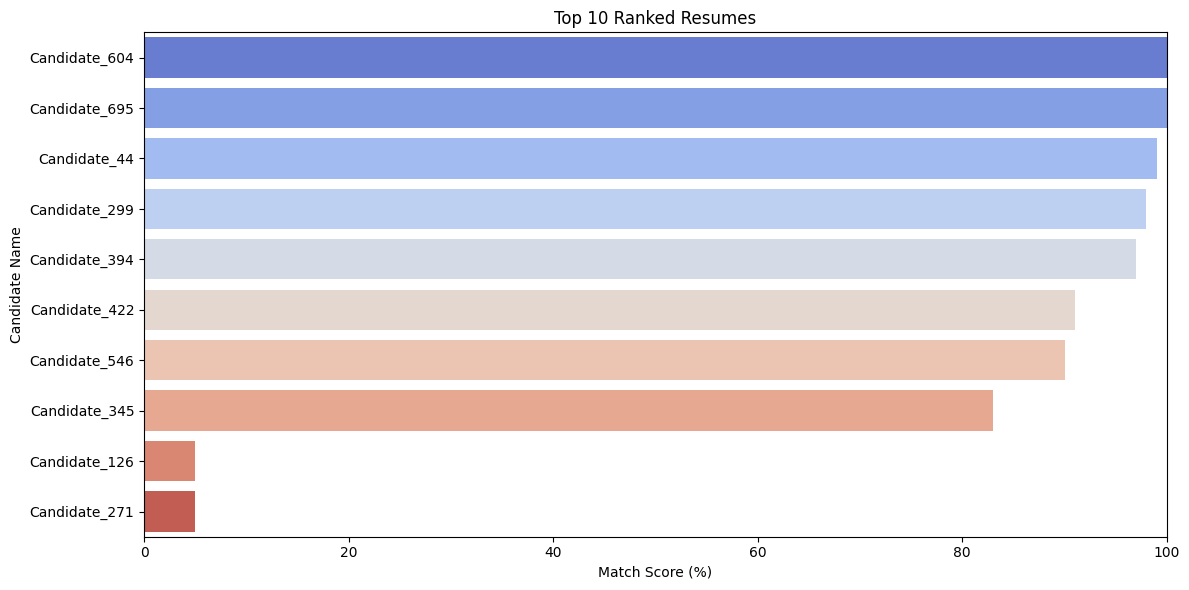

In [17]:
# Step 0: Install required packages (run once)
# !pip install pandas scikit-learn sentence-transformers matplotlib seaborn

# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load datasets
resumes = pd.read_csv("resumes_dataset_1000.csv")   # Columns: name, skills, education, experience_years, summary
jobs = pd.read_csv("job_descriptions_100.csv")      # Columns: job_id, title, required_skills, min_experience, preferred_education

# Step 3: Select a job description to rank resumes for
job_id = "Job_10"  # example
job_row = jobs[jobs['job_id'] == job_id]

if job_row.empty:
    raise ValueError(f"Job ID {job_id} not found. Please choose a valid job_id.")
job = job_row.iloc[0]

# Step 4: Extract job attributes
raw_skills = job.get('required_skills', '')
required_skills = [s.strip() for s in str(raw_skills).split(",") if s.strip()]
preferred_edu = job.get('preferred_education', 'BSc')
min_exp = job.get('min_experience', 1)

# Step 5: Preprocess resumes
resumes['Skills_List'] = resumes['skills'].apply(lambda x: [s.strip() for s in str(x).split(",") if s.strip()])

# Step 6: Compute Embeddings & Cosine Similarity with Job Description
model = SentenceTransformer('all-MiniLM-L6-v2')
jd_text = " ".join([str(job['title']), str(job['required_skills']), str(job['preferred_education'])])
jd_emb = model.encode([jd_text])

resumes['Resume_Embedding'] = resumes['summary'].apply(lambda x: model.encode([str(x)])[0])
resumes['Cosine_Sim'] = resumes['Resume_Embedding'].apply(lambda x: cosine_similarity([x], [jd_emb[0]])[0][0])

# Step 7: Compute Skill Match Ratio
def skill_match_ratio(candidate_skills, required_skills):
    matched = len(set([s.lower() for s in candidate_skills]) & set([s.lower() for s in required_skills]))
    return matched / len(required_skills) if required_skills else 0

resumes['Skill_Match'] = resumes['Skills_List'].apply(lambda x: skill_match_ratio(x, required_skills))

# Step 8: Experience Score
resumes['experience_years'] = resumes['experience_years'].fillna(0)
resumes['experience_score'] = resumes['experience_years'].apply(
    lambda x: min(max(0, x / min_exp), 1) if min_exp > 0 else 1
)

# Step 9: Education Score
edu_map = {'BSc': 0.5, 'MSc': 0.7, 'PhD': 1.0}
preferred_score = edu_map.get(preferred_edu, 0.5)
resumes['education_score'] = resumes['education'].map(edu_map).fillna(0.3)
resumes['education_score'] = resumes['education_score'].apply(lambda x: 1.0 if x >= preferred_score else x)

# Step 10: Weak Supervision Pseudo-labels using cosine similarity
def pseudo_label(sim):
    if sim >= 0.75:
        return 1
    elif sim < 0.5:
        return 0
    else:
        return 1  # treat middle range as positive

resumes['Label'] = resumes['Cosine_Sim'].apply(pseudo_label)

# Step 11: Train Random Forest to compute ML Match Score
features = ['Cosine_Sim', 'Skill_Match', 'experience_score', 'education_score']
X = resumes[features]
y = resumes['Label']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

resumes['ML_Score'] = rf.predict_proba(X)[:, 1]
resumes['ML_Score_Percent'] = resumes['ML_Score'] * 100

# Step 12: Rank Resumes (Top 10)
top_resumes = resumes.sort_values(by='ML_Score', ascending=False).head(10)

print(f"\nTop 10 Ranked Resumes for Job ID: {job_id}")
print(top_resumes[['name', 'Cosine_Sim', 'Skill_Match', 'experience_score', 'education_score', 'ML_Score_Percent']])

# Step 13: Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='ML_Score_Percent', y='name', data=top_resumes, palette='coolwarm')
plt.xlabel("Match Score (%)")
plt.ylabel("Candidate Name")
plt.title("Top 10 Ranked Resumes")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()